#Comparision of Deep learning models for plant disease detection using leaf image data

#  Extract ZIP

In [1]:
import zipfile

zip_path = "/content/PlantVillage_small.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


# Import lib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model


# Load Dataset

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "/content/PlantVillage_small"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    color_mode='rgb'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    color_mode='rgb'
)

Found 600 images belonging to 4 classes.
Found 150 images belonging to 4 classes.



# Show Sample Images (EDA)

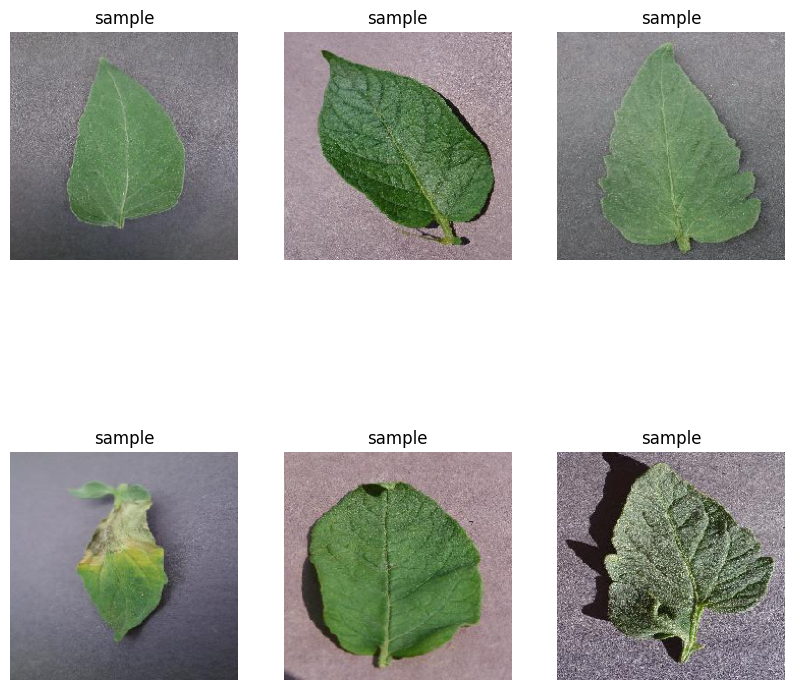

In [4]:

import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10,10))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("sample")
    plt.axis('off')
plt.show()

# Build CNN Model

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

# Compile and Train Model


In [6]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.4033 - loss: 2.9329 - val_accuracy: 0.6600 - val_loss: 1.0463
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.8167 - loss: 0.5508 - val_accuracy: 0.9267 - val_loss: 0.2925
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.9183 - loss: 0.2362 - val_accuracy: 0.8867 - val_loss: 0.3511
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9667 - loss: 0.0876 - val_accuracy: 0.9400 - val_loss: 0.1443
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9933 - loss: 0.0309 - val_accuracy: 0.9400 - val_loss: 0.1883
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.9967 - loss: 0.0180 - val_accuracy: 0.9200 - val_loss: 0.1943
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9933 - loss: 0.0217 - val_accuracy: 0.9467 - val_loss: 0.1536
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.9967 - loss: 0.0095 - val_accuracy: 0.9467 - val_loss:

# Plot Accuracy & Loss

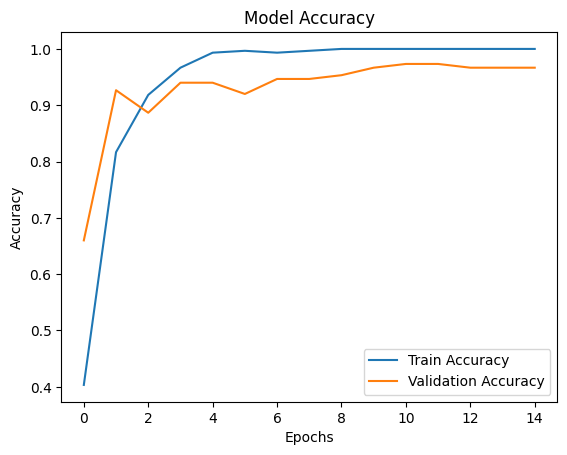

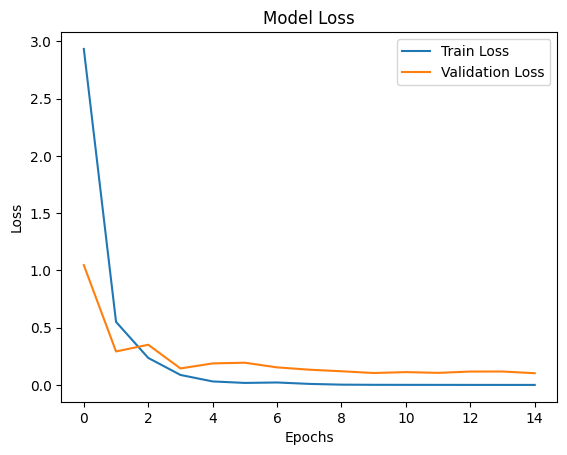

In [7]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Transfer Learning MODEL 1 - MobileNetV2



In [8]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=output)

tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_history = tl_model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.8033 - loss: 0.5470 - val_accuracy: 0.9667 - val_loss: 0.1198
Epoch 2/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.9733 - loss: 0.0777 - val_accuracy: 0.9800 - val_loss: 0.0637
Epoch 3/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9917 - loss: 0.0445 - val_accuracy: 0.9800 - val_loss: 0.0529
Epoch 4/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9917 - loss: 0.0289 - val_accuracy: 0.9867 - val_loss: 0.0460
Epoch 5/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.9950 - loss: 0.0181 - val_accuracy: 0.9867 - val_loss: 0.0390
Epoch 6/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9967 - loss: 0.0174 - val_accuracy: 0.9800 - val_loss: 0.0551
Epoch 7/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9967 - loss: 0.0213 - val_accuracy: 0.9800 - val_loss: 0.0407
Epoch 8/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 1.0000 - loss: 

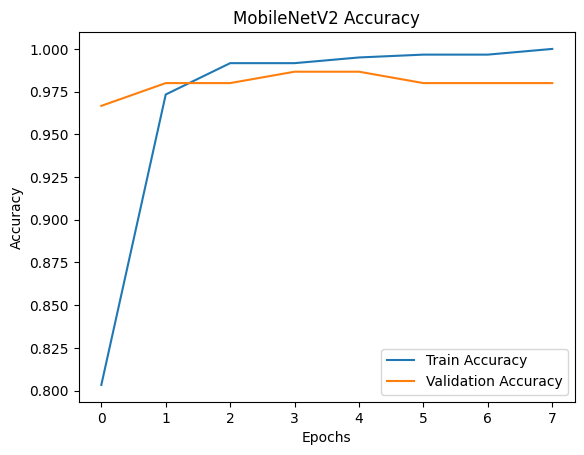

In [9]:
plt.plot(
    tl_history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    tl_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()